# Ghost-partition PINN flux reconstruction for the LCG interior-fracture case

Two-sided flux reconstruction on a domain split by a ghost extension of the physical fracture:

$$
q_{\theta}(x)=
\begin{cases}
q_\theta^+(x), & x \in \Omega^+,\\
q_\theta^-(x), & x \in \Omega^-.
\end{cases}
$$

On the physical fracture $\Gamma$, the normal jump $[\![q_\theta \cdot n]\!]$ is matched to $\lambda_h$ (or to $[\![q_{\rm cg}\cdot n]\!]$).  The **ghost partition** extends $\Gamma$ to the full diagonal of the bounding box so that both half-spaces cover the entire domain.

## 1. LCG reference solve

Run this notebook in the same directory as the `.msh` files, or update `filename` below.

In [10]:
from mpi4py import MPI
import gmsh
import numpy as np
from scipy.spatial import cKDTree
import pyvista as pv
from dolfinx import plot

N_ref = 8

Lx, Ly = 1.0, 1.0
y_start, y_end = 0.25, 0.75
x_start, x_end = 0.25, 0.75

#REFERENCE SOLUTION
from dolfinx import mesh, fem
import ufl
import numpy as np

# ---------------------------------------------------------------------
# 1. Mesh and interface tags (similar to Γ tagging in the workshop)
# ---------------------------------------------------------------------
# Load Gmsh mesh (2D bulk Ω + 1D interface Γ)
from dolfinx.io import gmsh as gmshio
ref = 5
filename = f"regular_mesh_with_fracture_interior_{ref}.msh"
msh, cell_markers, facet_markers = gmshio.read_from_msh(filename, MPI.COMM_WORLD, 0, gdim=2)[0:3]

tdim = msh.topology.dim  # 2
fdim = tdim - 1             # 1

lc = 1.0/ (2**ref)          # mesh size
h = lc

# Find all facets tagged as Gamma (tag=2)
omega = msh
gamma_entities = facet_markers.find(2)

# Create a submesh for Γ (same as gamma in the JSDokken example)
gamma, gamma_to_omega, gamma_vertex_to_omega = mesh.create_submesh(omega, fdim, gamma_entities)[0:3]

# Define interface tag ID (as defined in Gmsh)
Gamma_tag = 2  # <-- replace with your actual tag ID for the interface Γ

# ---------------------------------------------------------------------
# 2. Function spaces
# P1 for all three: optimal for conforming mesh (fracture aligned with matrix edges).
# P0 for λ is designed for nonconforming meshes where hλ can be chosen ≥ 2h independently.
# ---------------------------------------------------------------------
order = 1
V_m = fem.functionspace(omega, ("Lagrange", order))  # bulk Ω  — P1
V_f = fem.functionspace(gamma, ("Lagrange", order))   # interface Γ — P1
V_l = fem.functionspace(gamma, ("Lagrange", order))   # multiplier on Γ — P1 (conforming mesh)
W = ufl.MixedFunctionSpace(V_m, V_f, V_l)

# ---------------------------------------------------------------------
# 3. Trial and Test functions
# ---------------------------------------------------------------------
phi, psi, mu = ufl.TestFunctions(W)
dp_m, dp_f, dl = ufl.TrialFunctions(W)
p_m = fem.Function(V_m, name="p_m")
p_f = fem.Function(V_f, name="p_f")
lmbd = fem.Function(V_l, name="lmbd")

# ---------------------------------------------------------------------
# 4. Spatial coordinates and given data
# ---------------------------------------------------------------------
x = ufl.SpatialCoordinate(msh)
def f_callable(x):
    return -x[1]
f_m = fem.Function(V_m)
f_m.interpolate(f_callable)

f_f = fem.Function(V_f)
f_f.x.array[:] = 0.0

k_m = fem.Function(V_m)
def k_callable(x):
    vals = x[0]*2+1
    return vals[np.newaxis, :]
k_m.interpolate(k_callable)

k_f = fem.Function(V_f)
k_f.x.array[:] = 10.0

dx = ufl.Measure("dx", domain=omega)
dS_omega = ufl.Measure("dS", domain=omega)
ds = ufl.Measure("ds", domain=omega, subdomain_data=facet_markers, subdomain_id=Gamma_tag)
dx_f = ufl.Measure("dx", domain=gamma)

# Compute bounding box to locate sides
coords = omega.geometry.x
xx = coords[:, 0]
yy = coords[:, 1]

xmin, xmax = xx.min(), xx.max()
ymin, ymax = yy.min(), yy.max()

# Tolerance for side detection
tol = 1e-10 * max(xmax - xmin, ymax - ymin)

# Locate boundary facets for bottom (y = ymin) and top (y = ymax)
bottom_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymin, atol=tol)
)
top_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymax, atol=tol)
)

indices = np.concatenate([bottom_facets, top_facets]).astype(np.int32)
values = np.concatenate([
    np.full(bottom_facets.shape, 10, dtype=np.int32),
    np.full(top_facets.shape,    20, dtype=np.int32),
])

neumann_tags = mesh.meshtags(omega, fdim, indices, values)

dsN = ufl.Measure("ds", domain=omega)

g_N = ufl.conditional(
    ufl.lt(abs(x[1] - ymax), tol),
    -1.0,
    ufl.conditional(
        ufl.lt(abs(x[1] - ymin), tol),
        2.0,
        0.0
    ),
)

# ---------------------------------------------------------------------
# 5. Weak formulations
# ---------------------------------------------------------------------

# --- Bulk domain Ω ---------------------------------------------------
a_m0 = ufl.inner(k_m * ufl.grad(p_m), ufl.grad(phi)) * dx
a_m1 = -lmbd * phi * ds
a_m = a_m0 + a_m1
L_m = (
    f_m * phi * dx
)
L_m -= g_N * phi * dsN

# --- Interface Γ -----------------------------------------------------
a_f0 = ufl.inner(k_f * ufl.grad(p_f), ufl.grad(psi)) * ds
a_f1 = lmbd * psi * ds
a_f = a_f0 + a_f1
L_f = f_f * psi * ds

# --- Lagrange multiplier (constraint tr(p_m) = p_f) ------------------
a_l0 = p_m * mu * ds
a_l1 = -p_f * mu * ds
a_l = a_l0 + a_l1
L_l = fem.Constant(msh, 0.0) * mu * ds

# ---------------------------------------------------------------------
# 6. Combine interface weak form
# ---------------------------------------------------------------------
a_gamma = a_f + a_l
L_gamma = L_f + L_l

F = a_m - L_m + a_gamma - L_gamma
residual = ufl.extract_blocks(F)

jac = ufl.derivative(F, p_m, dp_m) + ufl.derivative(F, p_f, dp_f) + ufl.derivative(F, lmbd, dl)
J = ufl.extract_blocks(jac)

# Locate dofs on each side
left_dofs   = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmin, atol=tol))
right_dofs  = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmax, atol=tol))
bottom_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[1], ymin, atol=tol))
top_dofs    = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[1], ymax, atol=tol))

all_dofs = np.unique(np.concatenate([left_dofs, right_dofs]))

p_m_bc = fem.Function(V_m)
p_m_bc.x.array[left_dofs] = 1.0
p_m_bc.x.array[right_dofs]  = 4.0

bc_pm = fem.dirichletbc(p_m_bc, all_dofs)

tol_g = 1e-10 * np.max(np.ptp(gamma.geometry.x, axis=0))

tip1_dofs = fem.locate_dofs_geometrical(
    V_f,
    lambda x: np.logical_and(np.isclose(x[0], x_start, atol=tol_g),
                             np.isclose(x[1], y_start, atol=tol_g))
)
tip2_dofs = fem.locate_dofs_geometrical(
    V_f,
    lambda x: np.logical_and(np.isclose(x[0], x_end, atol=tol_g),
                             np.isclose(x[1], y_end, atol=tol_g))
)
both_tips = np.unique(np.concatenate([tip1_dofs, tip2_dofs]))

bcs = [bc_pm]

print("DOFs in p_m:", p_m.function_space.dofmap.index_map.size_global)
print("DOFs in p_f:", p_f.function_space.dofmap.index_map.size_global)
print("DOFs in λ:", lmbd.function_space.dofmap.index_map.size_global)
total_dofs = (
    p_m.function_space.dofmap.index_map.size_global
    + p_f.function_space.dofmap.index_map.size_global
    + lmbd.function_space.dofmap.index_map.size_global
)
print("Total DOFs:", total_dofs)

from dolfinx.fem import petsc
entity_maps = [gamma_to_omega]

nlp = petsc.NonlinearProblem(
    residual,
    u=[p_m, p_f, lmbd],
    J=J,
    bcs=bcs,
    entity_maps=entity_maps,
    petsc_options={
        "snes_monitor": None,
        "snes_max_it": 200,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "mat_mumps_icntl_14": 120,
        "ksp_error_if_not_converged": True,
        "snes_error_if_not_converged": True,
    },
    petsc_options_prefix="pmix_",
)
max_iterations = 25
normed_diff = 0
tol = 1e-5

nlp.solve()
iterations = nlp.solver.getIterationNumber()
print(f"Converged in {iterations} Newton iterations")

Info    : Reading 'regular_mesh_with_fracture_interior_5.msh'...
Info    : 9281 entities
Info    : 1089 nodes
Info    : 9281 elements
Info    : Done reading 'regular_mesh_with_fracture_interior_5.msh'
DOFs in p_m: 1089
DOFs in p_f: 17
DOFs in λ: 17
Total DOFs: 1123
  0 SNES Function norm 7.096363986956e+01
  1 SNES Function norm 6.401765311650e-13
Converged in 1 Newton iterations


## 2. Mesh, fracture, and CG flux utilities

In [11]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm
from dolfinx import geometry

torch.set_default_dtype(torch.float32)
SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Exact fracture endpoints from the original setup.
FRAC_A = np.array([x_start, y_start], dtype=float)
FRAC_B = np.array([x_end, y_end], dtype=float)

tdim = omega.topology.dim
fdim = tdim - 1
gdim = omega.geometry.dim
omega_geometry = omega.geometry.x[:, :2]

omega.topology.create_connectivity(tdim, 0)
omega.topology.create_connectivity(tdim, fdim)
omega.topology.create_connectivity(fdim, tdim)
omega.topology.create_connectivity(fdim, 0)

c2v = omega.topology.connectivity(tdim, 0)
cell_to_facet = omega.topology.connectivity(tdim, fdim)
facet_to_cell = omega.topology.connectivity(fdim, tdim)
facet_to_vertex = omega.topology.connectivity(fdim, 0)

num_cells = omega.topology.index_map(tdim).size_local
local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]

def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)

def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly

cell_polys = [order_polygon_vertices(omega_geometry[verts]) for verts in local_cell_vertices]
cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])
h_est = float(np.sqrt(np.mean(cell_areas)))
print("num cells:", num_cells, "h_est:", h_est)

# Build q_cg = -k_m grad(p_m).
Wq = fem.functionspace(omega, ("DG", order, (gdim,)))
q_cg_expr = fem.Expression(-k_m * ufl.grad(p_m), Wq.element.interpolation_points)
q_cg_fun = fem.Function(Wq, name="q_cg")
q_cg_fun.interpolate(q_cg_expr)

def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    points = np.asarray(points, dtype=float)
    pts3 = np.zeros((points.shape[0], 3), dtype=float)
    pts3[:, :2] = points[:, :2]
    tree = geometry.bb_tree(domain, domain.topology.dim)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(points.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((points.shape[0], 1), np.nan)
    valid_points = np.asarray(valid_points, dtype=float)
    valid_cells = np.asarray(valid_cells, dtype=np.int32)
    vals = np.asarray(fun.eval(valid_points, valid_cells))
    if vals.ndim == 1:
        vals = vals[:, None]
    out = np.full((points.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out

def q_cg_numpy(points):
    vals = eval_fem_function(q_cg_fun, points, omega)
    return vals[:, :2]

def f_numpy(points):
    vals = eval_fem_function(f_m, points, omega)
    return vals.reshape(-1)


device: cpu
num cells: 2048 h_est: 0.02209708691207961


## 3. Ghost extension partition

physical fracture: [0.25 0.25] to [0.75 0.75] length 0.7071067811865476
ghost line: [0. 0.] to [1. 1.]
tau: [0.70710678 0.70710678] normal: [-0.70710678  0.70710678]


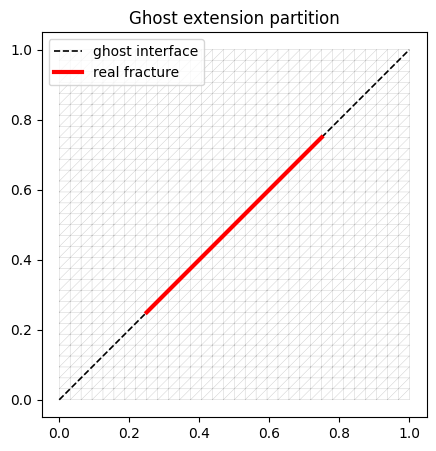

In [12]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0:
        raise ValueError("zero-length vector")
    return v / nrm

def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin, xmax, ymin, ymax = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin, xmax]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin - tol <= y <= ymax + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin, ymax]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin - tol <= x <= xmax + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box.")
    return min(ts), max(ts)

tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))
bbox = np.array([xmin, xmax, ymin, ymax], dtype=float)
t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, bbox)
GHOST_START = FRAC_A + t_min * tau_np
GHOST_END = FRAC_A + t_max * tau_np

def signed_distance_np(points):
    return (np.asarray(points, dtype=float) - FRAC_A) @ normal_np

def s_coord_np(points):
    return (np.asarray(points, dtype=float) - FRAC_A) @ tau_np

def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]

def ghost_points_np(n_each=160):
    pts = []
    if -t_min > 1e-14:
        s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
        pts.append(FRAC_A[None, :] + s_left[:, None] * tau_np[None, :])
    if t_max - L_gamma > 1e-14:
        s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
        pts.append(FRAC_A[None, :] + s_right[:, None] * tau_np[None, :])
    return np.vstack(pts) if pts else np.zeros((0, 2))

print("physical fracture:", FRAC_A, "to", FRAC_B, "length", L_gamma)
print("ghost line:", GHOST_START, "to", GHOST_END)
print("tau:", tau_np, "normal:", normal_np)

plt.figure(figsize=(5, 5))
plt.triplot(omega_geometry[:, 0], omega_geometry[:, 1], np.array(local_cell_vertices), lw=0.25, color="0.75")
plt.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]], "k--", lw=1.2, label="ghost interface")
plt.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=3, label="real fracture")
plt.gca().set_aspect("equal")
plt.legend()
plt.title("Ghost extension partition")
plt.show()


## 4. Multiplier data and sign convention

In [13]:
# Map gamma-submesh vertices back to omega vertices, following your original notebook.
imap_g = gamma.topology.index_map(0)
num_gamma_vertices = imap_g.size_local + imap_g.num_ghosts
gamma_vertices = np.arange(num_gamma_vertices, dtype=np.int32)
gamma_to_omega_vertices = gamma_vertex_to_omega.sub_topology_to_topology(
    gamma_vertices, inverse=False
)

lmbd_bulk_vertex = np.zeros(omega.geometry.x.shape[0], dtype=float)
lmbd_bulk_vertex[gamma_to_omega_vertices] = lmbd.x.array[:len(gamma_to_omega_vertices)]

gamma_set = set(np.asarray(gamma_entities, dtype=np.int32))

# Precompute half-cell multiplier integrals from tagged physical fracture facets.
lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
gamma_facet_records = []

for gf in gamma_entities:
    verts = np.asarray(facet_to_vertex.links(int(gf)), dtype=np.int32)
    x0 = omega.geometry.x[verts[0], :2]
    x1 = omega.geometry.x[verts[1], :2]
    length = float(np.linalg.norm(x1 - x0))
    lam_avg = 0.5 * (lmbd_bulk_vertex[verts[0]] + lmbd_bulk_vertex[verts[1]])
    s0 = float(s_coord_np(x0[None, :])[0])
    s1 = float(s_coord_np(x1[None, :])[0])
    if s1 < s0:
        s0, s1 = s1, s0
    for cell in facet_to_cell.links(int(gf)):
        if cell < num_cells:
            lambda_h_cell_int_raw[int(cell)] += 0.5 * length * lam_avg
            gamma_facet_records.append((int(cell), s0, s1, 0.5 * length))

# Exact int(q_cg.n) and int(f) on each cell using local FEniCSx assembly.
import basix
from dolfinx import mesh as dmesh

def precompute_cell_flux_and_source():
    cell_flux = np.zeros(num_cells, dtype=float)
    cell_source = np.zeros(num_cells, dtype=float)
    coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))
    loc_cells = np.array([[0, 1, 2]], dtype=np.int64)
    dummy_coords = np.zeros((3, gdim), dtype=omega_geometry.dtype)
    local_mesh = dmesh.create_mesh(MPI.COMM_SELF, loc_cells, coord_el, dummy_coords)
    P_loc = fem.functionspace(local_mesh, ("CG", order))
    p_K = fem.Function(P_loc)
    k_K = fem.Function(P_loc)
    f_K = fem.Function(P_loc)
    local_dofs = P_loc.dofmap.cell_dofs(0)
    n_K = ufl.FacetNormal(local_mesh)
    q_K = -k_K * ufl.grad(p_K)
    ds_K = ufl.ds(domain=local_mesh)
    dx_K = ufl.dx(domain=local_mesh)
    for cell_idx, verts in enumerate(tqdm(local_cell_vertices, desc="cell q/f integrals")):
        local_mesh.geometry.x[:, :gdim] = omega_geometry[verts]
        global_dofs = V_m.dofmap.cell_dofs(cell_idx)
        p_K.x.array[local_dofs] = p_m.x.array[global_dofs]
        k_K.x.array[local_dofs] = k_m.x.array[global_dofs]
        f_K.x.array[local_dofs] = f_m.x.array[global_dofs]
        p_K.x.scatter_forward()
        k_K.x.scatter_forward()
        f_K.x.scatter_forward()
        cell_flux[cell_idx]   = fem.assemble_scalar(fem.form(ufl.dot(q_K, n_K) * ds_K))
        cell_source[cell_idx] = fem.assemble_scalar(fem.form(f_K * dx_K))
    return cell_flux, cell_source

cell_flux_cg, cell_source = precompute_cell_flux_and_source()

R_plus = cell_flux_cg - cell_source - lambda_h_cell_int_raw
R_minus = cell_flux_cg - cell_source + lambda_h_cell_int_raw
if np.mean(np.abs(R_plus)) <= np.mean(np.abs(R_minus)):
    LAMBDA_SIGN = 1.0
    lambda_h_cell_int = lambda_h_cell_int_raw
else:
    LAMBDA_SIGN = -1.0
    lambda_h_cell_int = -lambda_h_cell_int_raw

print("auto LAMBDA_SIGN:", LAMBDA_SIGN)
print("mean |R_CG| with λ_h (sign selection only):", np.mean(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))
print("max  |R_CG| with λ_h (sign selection only):", np.max(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))

def lambda_h_on_s(s_query):
    """Raw LCG multiplier on the fracture.  From theory: [[q_m·n_Γ]] = lmbd directly."""
    pts = real_points_np(np.asarray(s_query, dtype=float).reshape(-1))
    vals = eval_fem_function(lmbd, pts, gamma).reshape(-1)
    return vals   # no LAMBDA_SIGN: raw lmbd IS the physical flux jump

cell q/f integrals: 100%|██████████| 2048/2048 [00:07<00:00, 268.45it/s]

auto LAMBDA_SIGN: -1.0
mean |R_CG| with λ_h (sign selection only): 0.00564521377550929
max  |R_CG| with λ_h (sign selection only): 1.0009804778613811


## 5. Interface target: lambda_h or CG flux jump

CONSERVATION_TARGET: CG flux jump  → lambda_h_cell_int updated


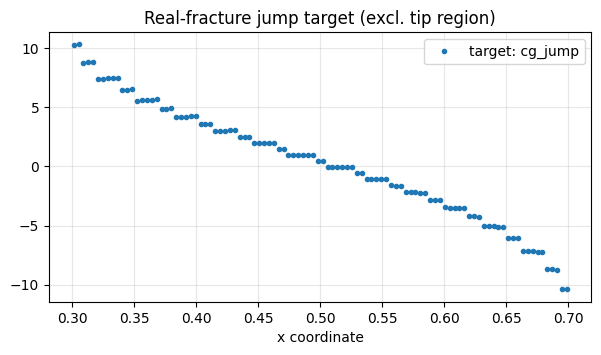

In [14]:
TARGET_MODE        = "cg_jump"  # options: "lambda_h" or "cg_jump"
CONSERVATION_TARGET = "cg_jump"  # options: "lambda_h" or "cg_jump"
TIP_FRAC = 0.1            # fraction of fracture length excluded from each tip
TIP_RADIUS_FACTOR = 10.0

def cg_jump_on_fracture(s_query, eps=None):
    if eps is None:
        eps = 0.35 * h_est
    s_query = np.asarray(s_query, dtype=float).reshape(-1)
    x0 = real_points_np(s_query)
    qp = q_cg_numpy(x0 + eps * normal_np[None, :])
    qm = q_cg_numpy(x0 - eps * normal_np[None, :])
    return np.sum((qp - qm) * normal_np[None, :], axis=1)

N_REAL = max(128, 4 * len(gamma_entities))
s_real = np.linspace(0.0, L_gamma, N_REAL)
x_real = real_points_np(s_real)
x_ghost = ghost_points_np(n_each=max(64, N_REAL // 2))

if TARGET_MODE == "lambda_h":
    lambda_target = lambda_h_on_s(s_real)
elif TARGET_MODE == "cg_jump":
    lambda_target = cg_jump_on_fracture(s_real)
else:
    raise ValueError("TARGET_MODE must be 'lambda_h' or 'cg_jump'.")

def tip_weight_np(s):
    s = np.asarray(s, dtype=float)
    d = np.minimum(s, L_gamma - s)
    radius = TIP_RADIUS_FACTOR * h_est
    return np.clip(d / max(radius, 1e-14), 0.0, 1.0)

w_tip  = tip_weight_np(s_real)
x_coords = x_real[:, 0]
t_real   = x_real[:, 0]

t_frac_len = x_end - x_start
mask_cmp = (
    (t_real >= x_start + TIP_FRAC * t_frac_len) &
    (t_real <= x_end   - TIP_FRAC * t_frac_len)
)

# ── Recompute lambda_h_cell_int based on CONSERVATION_TARGET ────────────
if CONSERVATION_TARGET == "cg_jump":
    # Batch all facet midpoints into a single cg_jump_on_fracture call to avoid
    # the shape-mismatch bug that occurs when evaluating a vector DG function at
    # a single point (eval returns shape (2,) which is misread as 2 scalar points).
    s_mids = np.array([0.5 * (s0 + s1) for _, s0, s1, _ in gamma_facet_records])
    cg_vals = cg_jump_on_fracture(s_mids)   # shape (N_records,)
    conservation_cell_int = np.zeros(num_cells, dtype=float)
    for i, (cell_id, s0, s1, half_length) in enumerate(gamma_facet_records):
        conservation_cell_int[int(cell_id)] += half_length * cg_vals[i]
    lambda_h_cell_int = conservation_cell_int
    print("CONSERVATION_TARGET: CG flux jump  → lambda_h_cell_int updated")
else:
    print("CONSERVATION_TARGET: lambda_h  (no change to lambda_h_cell_int)")

plt.figure(figsize=(7, 3.5))
plt.plot(x_coords[mask_cmp], lambda_target[mask_cmp], "o", ms=3, label=f"target: {TARGET_MODE}")
plt.xlabel("x coordinate")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.title("Real-fracture jump target (excl. tip region)")
plt.show()

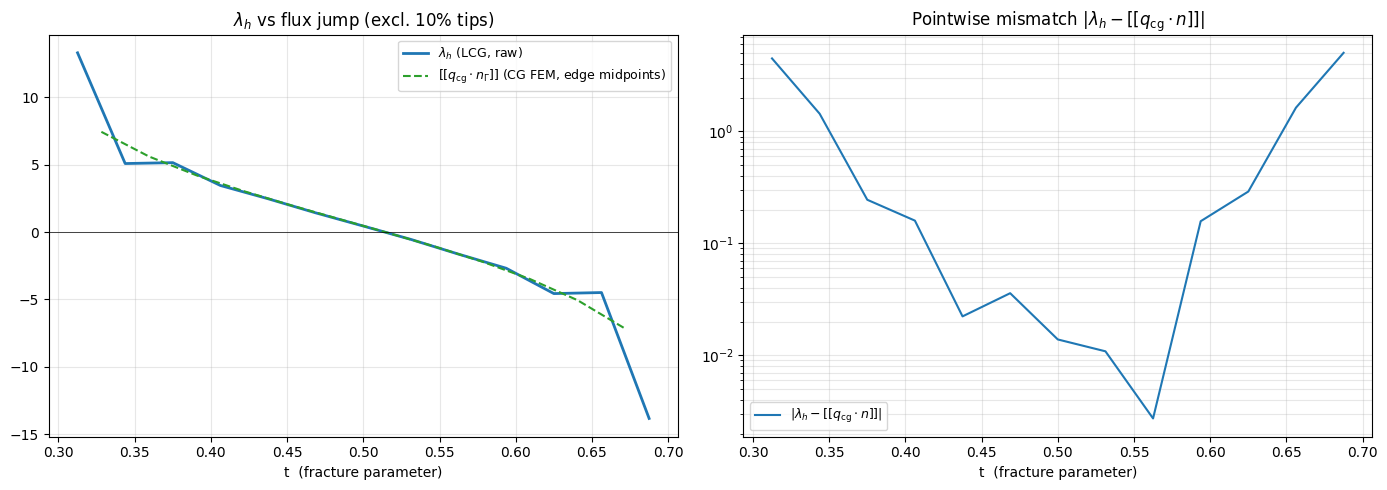

L2 mismatch |lambda_h - [[q_cg*n]]| (excl. 10% tips): 9.296e-01
lambda_h range:        [-13.843, 13.310]
[[q_cg*n]] range (midpoints): [-7.179, 7.441]


/tmp/ipykernel_579188/1762098094.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  l2_mismatch = np.sqrt(np.trapz(


In [15]:
# ── Lambda_h / CG flux-jump comparison ───────────────────────────────
# Theory (LCG weak form): [[q_m·n_Γ]] = lmbd  (raw FEM multiplier, no sign flip)
# So compare lmbd.x.array directly against cg_jump_on_fracture.
# LAMBDA_SIGN is used for the *conservation residual* diagnostic (R_K), not here.

dof_t_l_cmp = V_l.tabulate_dof_coordinates()[:, 0]   # x-coordinate of λ DOFs
idx_l_cmp   = np.argsort(dof_t_l_cmp)
t_l_cmp     = dof_t_l_cmp[idx_l_cmp]

lam_h_cmp = lmbd.x.array[idx_l_cmp]   # raw lmbd — NO LAMBDA_SIGN here

# CG Darcy-flux jump at edge MIDPOINTS (not DOF vertices).
# At a DOF vertex the ε-offset can land in an off-diagonal triangle,
# underestimating the jump; midpoints always land in fracture-adjacent elements.
t_mid       = 0.5 * (t_l_cmp[:-1] + t_l_cmp[1:])          # midpoints between consecutive DOF positions
s_mid       = (t_mid - x_start) * np.sqrt(2.0)              # arc-length from FRAC_A
cg_jump_mid = cg_jump_on_fracture(s_mid)                    # [[q_cg·n_Γ]] at midpoints

# Interpolate midpoint CG jump onto vertex grid for mismatch / L2 computation
cg_jump_at_vtx = np.interp(t_l_cmp, t_mid, cg_jump_mid)

t_frac_len_cmp = x_end - x_start
mask_l = (
    (t_l_cmp >= x_start + TIP_FRAC * t_frac_len_cmp) &
    (t_l_cmp <= x_end   - TIP_FRAC * t_frac_len_cmp)
)
mask_mid = (
    (t_mid >= x_start + TIP_FRAC * t_frac_len_cmp) &
    (t_mid <= x_end   - TIP_FRAC * t_frac_len_cmp)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_l_cmp[mask_l], lam_h_cmp[mask_l],
             lw=2, color='C0', label=r'$\lambda_h$ (LCG, raw)')
axes[0].plot(t_mid[mask_mid], cg_jump_mid[mask_mid],
             lw=1.5, ls='--', color='C2',
             label=r'$[[q_{\rm cg}\cdot n_\Gamma]]$ (CG FEM, edge midpoints)')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('t  (fracture parameter)')
axes[0].set_title(fr'$\lambda_h$ vs flux jump (excl. {TIP_FRAC*100:.0f}% tips)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(t_l_cmp[mask_l],
                 np.abs(lam_h_cmp[mask_l] - cg_jump_at_vtx[mask_l]) + 1e-16,
                 lw=1.5, color='C0', label=r'$|\lambda_h - [[q_{\rm cg}\cdot n]]|$')
axes[1].set_xlabel('t  (fracture parameter)')
axes[1].set_title(r'Pointwise mismatch $|\lambda_h - [[q_{\rm cg}\cdot n]]|$')
axes[1].legend(fontsize=9)
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

l2_mismatch = np.sqrt(np.trapz(
    (lam_h_cmp[mask_l] - cg_jump_at_vtx[mask_l])**2, t_l_cmp[mask_l]
))
print(f'L2 mismatch |lambda_h - [[q_cg*n]]| (excl. {TIP_FRAC*100:.0f}% tips): {l2_mismatch:.3e}')
print(f'lambda_h range:        [{lam_h_cmp[mask_l].min():.3f}, {lam_h_cmp[mask_l].max():.3f}]')
print(f'[[q_cg*n]] range (midpoints): [{cg_jump_mid[mask_mid].min():.3f}, {cg_jump_mid[mask_mid].max():.3f}]')


## 6. Neural flux model

In [35]:
class AdaptiveTanh(nn.Module):
    def __init__(self, n=5.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.0 / n))
    def forward(self, x):
        return torch.tanh(self.a * x)

class FluxNet(nn.Module):
    def __init__(self, in_dim=2, out_dim=2, hidden_dim=64, num_hidden_layers=4, n=5.0):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), AdaptiveTanh(n=n)]
        for _ in range(num_hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), AdaptiveTanh(n=n)]
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)
    def slope_recovery_term(self):
        slopes = [m.a for m in self.net if isinstance(m, AdaptiveTanh)]
        return 1.0 / torch.mean(torch.exp(torch.stack(slopes)))

xy_center_np = np.array([(xmin + xmax) / 2.0, (ymin + ymax) / 2.0], dtype=float)
xy_scale = float(max(xmax - xmin, ymax - ymin))

xy_center_t = torch.tensor(xy_center_np, dtype=torch.float32, device=device)
tau_t        = torch.tensor(tau_np,       dtype=torch.float32, device=device)
normal_t     = torch.tensor(normal_np,    dtype=torch.float32, device=device)
frac_a_t     = torch.tensor(FRAC_A,      dtype=torch.float32, device=device)

def to_torch(x, requires_grad=False):
    t = torch.as_tensor(np.asarray(x, dtype=np.float32), device=device)
    if requires_grad:
        t = t.clone().detach().requires_grad_(True)
    return t

def normalize_xy(x):
    return (x - xy_center_t) / xy_scale

q_plus_net = FluxNet(hidden_dim=32, num_hidden_layers=3).to(device)
q_minus_net = FluxNet(hidden_dim=32, num_hidden_layers=3).to(device)

def signed_distance_torch(x):
    return (x - frac_a_t) @ normal_t

def s_coord_torch(x):
    return (x - frac_a_t) @ tau_t

def q_plus(x):
    return q_plus_net(normalize_xy(x))

def q_minus(x):
    return q_minus_net(normalize_xy(x))

def q_piecewise(x):
    phi = signed_distance_torch(x)
    qp = q_plus(x)
    qm = q_minus(x)
    return torch.where((phi >= 0.0).reshape(-1, 1), qp, qm)

def div_of_q(net_fn, x):
    x = x.clone().detach().requires_grad_(True)
    q = net_fn(x)
    dq0 = torch.autograd.grad(q[:, 0].sum(), x, create_graph=True)[0][:, 0]
    dq1 = torch.autograd.grad(q[:, 1].sum(), x, create_graph=True)[0][:, 1]
    return dq0 + dq1


## 7. Training data

In [36]:
N_PTS_PER_EDGE = 3  # sample points per mesh edge (interior, excluding vertices)
MASK_FACTOR_START = 0.15
MASK_FACTOR_END = 1.15

# Flux data at edge sample points, away from the fracture.
num_facets = omega.topology.index_map(fdim).size_local
edge_sample_pts = []
for f in range(num_facets):
    verts = facet_to_vertex.links(f)
    x0 = omega_geometry[verts[0]]
    x1 = omega_geometry[verts[1]]
    ts = np.linspace(0.0, 1.0, N_PTS_PER_EDGE + 2)[1:-1]
    for t in ts:
        edge_sample_pts.append(x0 + t * (x1 - x0))
edge_sample_pts = np.array(edge_sample_pts, dtype=float)

phi_edge = signed_distance_np(edge_sample_pts)
Q_data_all = q_cg_numpy(edge_sample_pts)
valid = np.all(np.isfinite(Q_data_all), axis=1)
X_data = edge_sample_pts[valid]
Q_data = Q_data_all[valid]
phi_data = phi_edge[valid]
data_mask = np.abs(phi_data) > MASK_FACTOR_START * h_est
data_mask_final = np.abs(phi_data) > MASK_FACTOR_END * h_est

X_data_t = to_torch(X_data)
Q_data_t = to_torch(Q_data)
data_idx_start_t = torch.tensor(np.nonzero(data_mask)[0], dtype=torch.long, device=device)
data_idx_final_t = torch.tensor(np.nonzero(data_mask_final)[0], dtype=torch.long, device=device)

# Divergence collocation at cell centroids, with the same staged near-fracture exclusion as data.
X_div = cell_centroids
F_div = f_numpy(X_div)
phi_div = signed_distance_np(X_div)
div_mask = np.abs(phi_div) > MASK_FACTOR_START * h_est
div_mask_final = np.abs(phi_div) > MASK_FACTOR_END * h_est
X_div_t = to_torch(X_div)
F_div_t = to_torch(F_div)
div_idx_start_t = torch.tensor(np.nonzero(div_mask)[0], dtype=torch.long, device=device)
div_idx_final_t = torch.tensor(np.nonzero(div_mask_final)[0], dtype=torch.long, device=device)
side_div_t = signed_distance_torch(X_div_t) >= 0.0

# Interface tensors.
X_real_t = to_torch(x_real)
Lambda_target_t = to_torch(lambda_target)
W_tip_t = to_torch(w_tip)
X_ghost_t = to_torch(x_ghost)

print(f'flux data pool (edge-sampled, {N_PTS_PER_EDGE} pts/edge):', len(X_data))
print(f'data_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):',
      data_idx_start_t.numel(), '->', data_idx_final_t.numel())
print('div collocation pool:', len(X_div))
print(f'div_mask points ({MASK_FACTOR_START:.2f}h -> {MASK_FACTOR_END:.2f}h):',
      div_idx_start_t.numel(), '->', div_idx_final_t.numel())
print('real interface points:', len(x_real))
print('ghost interface points:', len(x_ghost))

# Helper functions for post-training diagnostics.
def build_edge_quadrature_for_cells(cell_ids):
    xi = np.array([0.5 * (1 - 1 / np.sqrt(3)), 0.5 * (1 + 1 / np.sqrt(3))], dtype=float)
    wi = np.array([0.5, 0.5], dtype=float)
    edge_points, edge_nw, edge_cells = [], [], []
    is_gamma_edge = []  # True for quadrature points on the physical fracture edge
    source, cg_flux, lambda_h_int = [], [], []
    local_id_of_cell = {}
    eps_side = 1e-10  # offset fracture-edge points toward centroid so phi != 0
    for local_i, cell_id in enumerate(cell_ids):
        local_id_of_cell[int(cell_id)] = local_i
        poly = cell_polys[int(cell_id)]
        centroid = cell_centroids[int(cell_id)]
        source.append(cell_source[int(cell_id)])
        cg_flux.append(cell_flux_cg[int(cell_id)])
        lambda_h_int.append(lambda_h_cell_int[int(cell_id)])
        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            n_len = np.array([edge[1], -edge[0]], dtype=float)
            for q, w in zip(xi, wi):
                pt = x0 + q * edge
                phi_pt = signed_distance_np(pt[None, :])[0]
                s_pt = s_coord_np(pt[None, :])[0]
                on_gamma = (abs(phi_pt) < 1e-12) and (-1e-12 <= s_pt <= L_gamma + 1e-12)
                # If pt lies exactly on gamma (phi=0), q_piecewise always
                # picks q+. Offset toward the element centroid so the point
                # lands on the correct side (K+ uses q+, K- uses q-).
                if on_gamma:
                    d = centroid - pt
                    pt = pt + eps_side * d / (np.linalg.norm(d) + 1e-30)
                edge_points.append(pt)
                edge_nw.append(w * n_len)
                edge_cells.append(local_i)
                is_gamma_edge.append(on_gamma)
    return {
        'cell_ids': np.asarray(cell_ids, dtype=np.int32),
        'edge_points': np.asarray(edge_points),
        'edge_nw': np.asarray(edge_nw),
        'edge_cells': np.asarray(edge_cells, dtype=np.int64),
        'is_gamma_edge': np.asarray(is_gamma_edge, dtype=bool),
        'source': np.asarray(source),
        'cg_flux': np.asarray(cg_flux),
        'lambda_h_int': np.asarray(lambda_h_int),
        'local_id_of_cell': local_id_of_cell,
    }

def attach_gamma_facets_to_cell_data(data):
    gamma_cell_local, gamma_s0, gamma_s1, gamma_half_length = [], [], [], []
    local_id_of_cell = data['local_id_of_cell']
    for cell_id, s0, s1, half_length in gamma_facet_records:
        if cell_id in local_id_of_cell:
            gamma_cell_local.append(local_id_of_cell[cell_id])
            gamma_s0.append(s0)
            gamma_s1.append(s1)
            gamma_half_length.append(half_length)
    data['gamma_cell_local'] = np.asarray(gamma_cell_local, dtype=np.int64)
    data['gamma_s0'] = np.asarray(gamma_s0, dtype=float)
    data['gamma_s1'] = np.asarray(gamma_s1, dtype=float)
    data['gamma_half_length'] = np.asarray(gamma_half_length, dtype=float)
    return data


flux data pool (edge-sampled, 3 pts/edge): 9408
data_mask points (0.15h -> 1.15h): 9312 -> 8742
div collocation pool: 2048
div_mask points (0.15h -> 1.15h): 2048 -> 1922
real interface points: 128
ghost interface points: 128


## 8. Train

In [37]:
W_DATA     = 1.0
W_DIV      = 0.1
W_CONS_INT = 1.0   # final interior, CG-relative conservation hinge weight
W_CONS_TIP = 1.0   # final tip boundedness weight
W_JUMP     = 2.0
W_GHOST    = 0.5
W_SLOPE    = 1e-4

CONS_INT_BETA = 0.01   # beta < 1 asks for strict improvement over CG away from tips
CONS_R_FLOOR  = 1e-5
CONS_INT_GAMMA = 4.0  # extra penalty multiplier when PINN residual exceeds beta*CG

EPOCHS = 10000
LR_PLUS  = 1e-3
LR_MINUS = 1e-3
PRINT_EVERY = 250

BATCH_DATA = 8192
BATCH_DIV  = 4096

CONS_RAMP_START_FRAC = 0.60
CONS_RAMP_END_FRAC   = 0.90
CONS_RAMP_START = int(CONS_RAMP_START_FRAC * EPOCHS)
CONS_RAMP_END   = int(CONS_RAMP_END_FRAC   * EPOCHS)
BEST_START_EPOCH = CONS_RAMP_END

# Precompute edge quadrature for fracture-adjacent cells (used in conservation loss).
_frac_cids  = np.unique([cid for cid, _, _, _ in gamma_facet_records])
_frac_quad  = build_edge_quadrature_for_cells(_frac_cids)
N_frac_cons = len(_frac_cids)
frac_eq_pts_t      = to_torch(_frac_quad['edge_points'])
frac_eq_nw_t       = to_torch(_frac_quad['edge_nw'])
frac_eq_cells_t    = torch.tensor(_frac_quad['edge_cells'],    dtype=torch.long, device=device)
frac_eq_is_gamma_t = torch.tensor(_frac_quad['is_gamma_edge'], dtype=torch.bool, device=device)
frac_source_t      = to_torch(_frac_quad['source'])
frac_lambda_t      = to_torch(_frac_quad['lambda_h_int'])

# CG residual on the same non-fracture-edge quadrature used by the PINN conservation loss.
_nf_np = ~_frac_quad['is_gamma_edge']
_q_cg_nf = q_cg_numpy(_frac_quad['edge_points'][_nf_np])
_flux_cg_q = np.sum(_q_cg_nf * _frac_quad['edge_nw'][_nf_np], axis=1)
_flux_cg_K = np.zeros(N_frac_cons, dtype=float)
np.add.at(_flux_cg_K, _frac_quad['edge_cells'][_nf_np], _flux_cg_q)
frac_R_cg_np = _flux_cg_K - _frac_quad['source'] - _frac_quad['lambda_h_int']
frac_R_cg_t = to_torch(frac_R_cg_np)

# Split fracture-adjacent conservation cells into tip and interior sets.
frac_s_np = s_coord_np(cell_centroids[_frac_cids])
frac_cons_tip_np = (frac_s_np < TIP_FRAC * L_gamma) | (frac_s_np > (1.0 - TIP_FRAC) * L_gamma)
frac_cons_int_np = ~frac_cons_tip_np
frac_cons_tip_t = torch.tensor(frac_cons_tip_np, dtype=torch.bool, device=device)
frac_cons_int_t = torch.tensor(frac_cons_int_np, dtype=torch.bool, device=device)

# Non-fracture-edge indices (precomputed once — mask is fixed).
nf_mask          = ~frac_eq_is_gamma_t
frac_eq_pts_nf   = frac_eq_pts_t[nf_mask]
frac_eq_nw_nf    = frac_eq_nw_t[nf_mask]
frac_eq_cells_nf = frac_eq_cells_t[nf_mask]
print(f'fracture-adjacent cells for conservation loss: {N_frac_cons}')
print(f'  total quad pts: {len(frac_eq_pts_t)},  non-fracture-edge pts: {nf_mask.sum().item()}')
print(f'  interior cells: {int(frac_cons_int_np.sum())}, tip cells: {int(frac_cons_tip_np.sum())}')
print(f'conservation curriculum: ramp {CONS_RAMP_START} -> {CONS_RAMP_END}; best starts at {BEST_START_EPOCH}')

optimizer_plus  = torch.optim.Adam(q_plus_net.parameters(),  lr=LR_PLUS)
optimizer_minus = torch.optim.Adam(q_minus_net.parameters(), lr=LR_MINUS)
scheduler_plus  = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_plus,
    milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)],
    gamma=0.35,
)
scheduler_minus = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_minus,
    milestones=[int(0.45 * EPOCHS), int(0.75 * EPOCHS)],
    gamma=0.35,
)

def mse(x):
    return torch.mean(x ** 2)

def smoothstep01(x):
    x = min(max(float(x), 0.0), 1.0)
    return x * x * (3.0 - 2.0 * x)

def curriculum_for_epoch(epoch):
    if CONS_RAMP_END <= CONS_RAMP_START:
        ramp = 1.0
    else:
        ramp = smoothstep01((epoch - CONS_RAMP_START) / (CONS_RAMP_END - CONS_RAMP_START))
    use_final_mask = epoch >= CONS_RAMP_START
    mask_factor = MASK_FACTOR_END if use_final_mask else MASK_FACTOR_START
    data_pool = data_idx_final_t if use_final_mask else data_idx_start_t
    div_pool = div_idx_final_t if use_final_mask else div_idx_start_t
    return ramp, mask_factor, data_pool, div_pool

def snapshot_state():
    return {
        'q_plus':  {k: v.detach().cpu().clone() for k, v in q_plus_net.state_dict().items()},
        'q_minus': {k: v.detach().cpu().clone() for k, v in q_minus_net.state_dict().items()},
    }

def compute_loss_terms(epoch):
    cons_ramp, mask_factor, data_pool, div_pool = curriculum_for_epoch(epoch)

    # mini-batch flux data
    n_data_epoch = data_pool.numel()
    idx_d_local = torch.randint(0, n_data_epoch, (min(BATCH_DATA, n_data_epoch),), device=device)
    idx_d = data_pool[idx_d_local]
    x_d = X_data_t[idx_d]
    q_d = Q_data_t[idx_d]
    loss_data = mse(q_piecewise(x_d) - q_d)

    # mini-batch div collocation (cell centroids)
    n_div_epoch = div_pool.numel()
    idx_v_local = torch.randint(0, n_div_epoch, (min(BATCH_DIV, n_div_epoch),), device=device)
    idx_v = div_pool[idx_v_local]
    x_div_b = X_div_t[idx_v]
    f_div_b = F_div_t[idx_v]
    side_b  = side_div_t[idx_v]

    div_loss = torch.tensor(0.0, device=device)
    Xp = x_div_b[side_b];  fp = f_div_b[side_b]
    Xm = x_div_b[~side_b]; fm = f_div_b[~side_b]
    if Xp.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_plus, Xp) - fp)
    if Xm.numel() > 0:
        div_loss = div_loss + mse(div_of_q(q_minus, Xm) - fm)

    # Conservation loss for fracture-adjacent elements.
    # Only non-fracture edges contribute to the flux integral;
    # the fracture acts as a source term lambda_h_int[K] on the RHS.
    # Balance: ∫_{e1}+∫_{e2} q·n ds = ∫_K f dx + lambda_h_int[K]
    q_nf     = q_piecewise(frac_eq_pts_nf)
    flux_q   = torch.sum(q_nf * frac_eq_nw_nf, dim=1)
    flux_K   = torch.zeros(N_frac_cons, device=device)
    flux_K.scatter_add_(0, frac_eq_cells_nf, flux_q)
    R_rec_frac = flux_K - frac_source_t - frac_lambda_t
    loss_cons_frac = mse(R_rec_frac)

    loss_cons_int = torch.tensor(0.0, device=device)
    if frac_cons_int_t.any().item():
        R_rec_int = R_rec_frac[frac_cons_int_t]
        R_cg_int = frac_R_cg_t[frac_cons_int_t]
        R_cg_abs = torch.abs(R_cg_int)
        denom = torch.clamp(R_cg_abs, min=CONS_R_FLOOR)
        r_norm = R_rec_int / denom
        excess = torch.relu(torch.abs(R_rec_int) - CONS_INT_BETA * R_cg_abs)
        # base term always pushes R_K(q_theta)->0; extra term penalises when worse than CG
        loss_cons_int = torch.mean(r_norm ** 2) + CONS_INT_GAMMA * torch.mean((excess / denom) ** 2)

    loss_cons_tip = torch.tensor(0.0, device=device)
    if frac_cons_tip_t.any().item():
        loss_cons_tip = mse(R_rec_frac[frac_cons_tip_t])

    # full interface / ghost / slope (small tensors, always use all)
    qp_real = q_plus(X_real_t)
    qm_real = q_minus(X_real_t)
    jump_real = torch.sum((qp_real - qm_real) * normal_t.reshape(1, 2), dim=1)
    loss_jump = torch.mean(W_tip_t * (jump_real - Lambda_target_t) ** 2)

    loss_ghost = mse(q_plus(X_ghost_t) - q_minus(X_ghost_t)) if X_ghost_t.numel() > 0 \
                 else torch.tensor(0.0, device=device)

    loss_slope = q_plus_net.slope_recovery_term() + q_minus_net.slope_recovery_term()

    total = (
        W_DATA * loss_data
        + W_DIV * div_loss
        + (cons_ramp * W_CONS_INT) * loss_cons_int
        + (cons_ramp * W_CONS_TIP) * loss_cons_tip
        + W_JUMP * loss_jump
        + W_GHOST * loss_ghost
        + W_SLOPE * loss_slope
    )
    parts = {
        'data':        loss_data.detach(),
        'div':         div_loss.detach(),
        'cons_frac':   loss_cons_frac.detach(),
        'cons_int':    loss_cons_int.detach(),
        'cons_tip':    loss_cons_tip.detach(),
        'jump':        loss_jump.detach(),
        'ghost':       loss_ghost.detach(),
        'slope':       loss_slope.detach(),
        'cons_ramp':   torch.tensor(cons_ramp, device=device),
        'mask_factor': torch.tensor(mask_factor, device=device),
        'n_data_mask': torch.tensor(float(n_data_epoch), device=device),
        'n_div_mask':  torch.tensor(float(n_div_epoch), device=device),
    }
    return total, parts

history = []
best = {'loss': float('inf'), 'state': None, 'epoch': 0}

for epoch in range(1, EPOCHS + 1):
    optimizer_plus.zero_grad(set_to_none=True)
    optimizer_minus.zero_grad(set_to_none=True)
    loss, parts = compute_loss_terms(epoch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(q_plus_net.parameters(),  max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(q_minus_net.parameters(), max_norm=1.0)
    optimizer_plus.step()
    optimizer_minus.step()
    scheduler_plus.step()
    scheduler_minus.step()

    if epoch >= BEST_START_EPOCH and float(loss.detach().cpu()) < best['loss']:
        best['loss'] = float(loss.detach().cpu())
        best['epoch'] = epoch
        best['state'] = snapshot_state()

    if epoch == 1 or epoch % PRINT_EVERY == 0:
        row = {'epoch': epoch, 'total': float(loss.detach().cpu())}
        row.update({k: float(v.cpu()) for k, v in parts.items()})
        history.append(row)
        print(
            f"{epoch:6d} total={row['total']:.3e} data={row['data']:.3e} "
            f"div={row['div']:.3e} cons_int={row['cons_int']:.3e} "
            f"cons_tip={row['cons_tip']:.3e} cons_frac={row['cons_frac']:.3e} "
            f"jump={row['jump']:.3e} ghost={row['ghost']:.3e} "
            f"ramp={row['cons_ramp']:.2f} mask={row['mask_factor']:.2f}h"
        )
        if epoch >= BEST_START_EPOCH and row['total'] < 1e-8:
            print("Early stopping criterion met (total loss < 1e-8).")
            break

if best['state'] is None:
    best['loss'] = float(loss.detach().cpu())
    best['epoch'] = epoch
    best['state'] = snapshot_state()

q_plus_net.load_state_dict(best['state']['q_plus'])
q_minus_net.load_state_dict(best['state']['q_minus'])
print('restored best epoch:', best['epoch'], 'loss:', best['loss'])


fracture-adjacent cells for conservation loss: 32
  total quad pts: 192,  non-fracture-edge pts: 128
  interior cells: 24, tip cells: 8
conservation curriculum: ramp 6000 -> 9000; best starts at 9000
     1 total=5.039e+01 data=1.767e+01 div=6.452e-01 cons_int=1.793e+00 cons_tip=9.163e-02 cons_frac=2.949e-02 jump=1.633e+01 ghost=9.276e-03 ramp=0.00 mask=0.15h
   250 total=2.271e+01 data=2.142e+00 div=4.956e-01 cons_int=5.508e+00 cons_tip=7.538e-02 cons_frac=4.051e-02 jump=6.403e+00 ghost=1.542e+01 ramp=0.00 mask=0.15h
   500 total=5.983e+00 data=2.500e+00 div=2.722e-01 cons_int=6.224e+00 cons_tip=9.043e-02 cons_frac=4.798e-02 jump=1.286e+00 ghost=1.766e+00 ramp=0.00 mask=0.15h
   750 total=3.358e+00 data=2.251e+00 div=6.559e-01 cons_int=5.875e+00 cons_tip=1.046e-01 cons_frac=4.972e-02 jump=3.659e-01 ghost=6.200e-01 ramp=0.00 mask=0.15h
  1000 total=2.434e+00 data=1.659e+00 div=6.016e-01 cons_int=5.632e+00 cons_tip=1.072e-01 cons_frac=4.899e-02 jump=2.591e-01 ghost=3.924e-01 ramp=0.00 m

## 9. Diagnostics: local conservation and interface jump

CG local conservation:
  mean |R_K|: 0.015220188211824465
  max  |R_K|: 0.9900525625704159
Ghost-partition PINN reconstruction:
  mean |R_K|: 0.0028423585716836897
  max  |R_K|: 0.43005267670227393


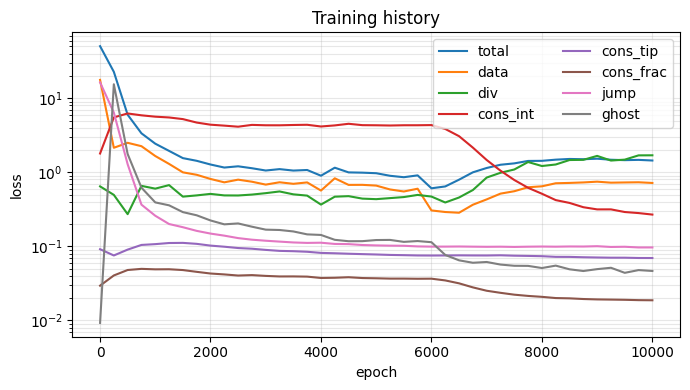

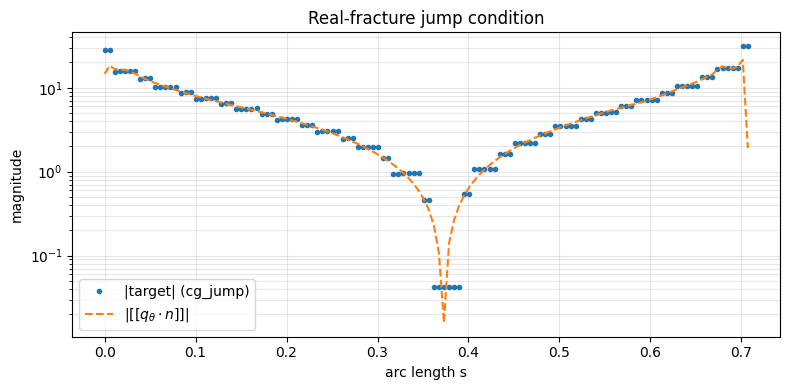

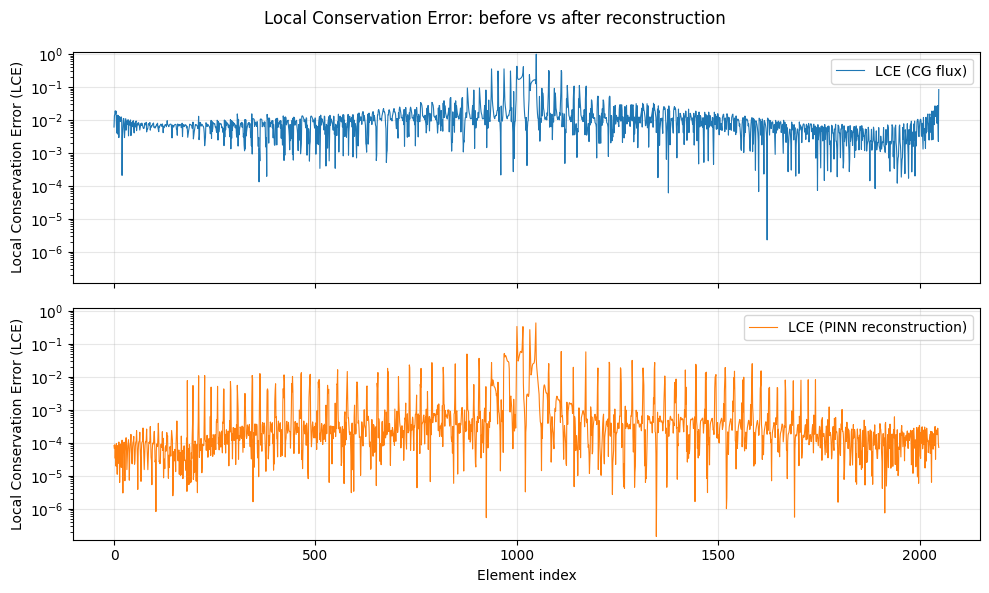

In [38]:
@torch.no_grad()
def q_rec_numpy(points):
    return q_piecewise(to_torch(points)).detach().cpu().numpy()

@torch.no_grad()
def jump_rec_numpy(s):
    xq = real_points_np(np.asarray(s, dtype=float).reshape(-1))
    return torch.sum(
        (q_plus(to_torch(xq)) - q_minus(to_torch(xq))) * normal_t.reshape(1, 2), dim=1
    ).detach().cpu().numpy()

def residual_for_cell_data_numpy(cell_ids):
    data = attach_gamma_facets_to_cell_data(build_edge_quadrature_for_cells(cell_ids))
    # Match loss_cons_frac: for fracture-adjacent cells, the fracture
    # edge is not a boundary-flux edge; lambda_h_int is the source term.
    active = ~data["is_gamma_edge"]

    q_edges_rec = q_rec_numpy(data["edge_points"][active])
    edge_flux_rec = np.sum(q_edges_rec * data["edge_nw"][active], axis=1)
    flux_rec = np.zeros(len(data["source"]))
    np.add.at(flux_rec, data["edge_cells"][active], edge_flux_rec)

    q_edges_cg = q_cg_numpy(data["edge_points"][active])
    edge_flux_cg = np.sum(q_edges_cg * data["edge_nw"][active], axis=1)
    flux_cg = np.zeros(len(data["source"]))
    np.add.at(flux_cg, data["edge_cells"][active], edge_flux_cg)

    R_rec = flux_rec - data["source"] - data["lambda_h_int"]
    R_cg  = flux_cg  - data["source"] - data["lambda_h_int"]
    return data, R_cg, R_rec

all_cell_ids = np.arange(num_cells)
diag_data, R_cg, R_rec = residual_for_cell_data_numpy(all_cell_ids)

print("CG local conservation:")
print("  mean |R_K|:", np.mean(np.abs(R_cg)))
print("  max  |R_K|:", np.max(np.abs(R_cg)))
print("Ghost-partition PINN reconstruction:")
print("  mean |R_K|:", np.mean(np.abs(R_rec)))
print("  max  |R_K|:", np.max(np.abs(R_rec)))

hist = {k: np.array([row[k] for row in history]) for k in history[0].keys()}
plt.figure(figsize=(7, 4))
for key in ["total", "data", "div", "cons_int", "cons_tip", "cons_frac", "jump", "ghost"]:
    plt.semilogy(hist["epoch"], hist[key], label=key)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(True, which="both", alpha=0.3)
plt.legend(ncol=2)
plt.title("Training history")
plt.tight_layout()
plt.show()

jump_rec = jump_rec_numpy(s_real)

plt.figure(figsize=(8, 4))
plt.semilogy(s_real, np.abs(lambda_target) + 1e-16, "o", ms=3, label=f"|target| ({TARGET_MODE})")
plt.semilogy(s_real, np.abs(jump_rec)       + 1e-16, "--",        label=r"|$[[q_\theta \cdot n]]$|")
plt.xlabel("arc length s")
plt.ylabel("magnitude")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.title("Real-fracture jump condition")
plt.tight_layout()
plt.show()

# LCE by element index: before vs after reconstruction, using one common y-scale.
lce_eps = 1e-16
lce_cg = np.abs(R_cg) + lce_eps
lce_rec = np.abs(R_rec) + lce_eps
lce_ymin = max(lce_eps, min(lce_cg.min(), lce_rec.min()) * 0.8)
lce_ymax = max(lce_cg.max(), lce_rec.max()) * 1.2

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
axes[0].semilogy(np.arange(len(R_cg)), lce_cg, linewidth=0.8, label="LCE (CG flux)")
axes[0].set_ylabel("Local Conservation Error (LCE)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].semilogy(np.arange(len(R_rec)), lce_rec, linewidth=0.8, color="tab:orange", label="LCE (PINN reconstruction)")
axes[1].set_ylabel("Local Conservation Error (LCE)")
axes[1].set_xlabel("Element index")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
for ax in axes:
    ax.set_ylim(lce_ymin, lce_ymax)
plt.suptitle("Local Conservation Error: before vs after reconstruction")
plt.tight_layout()
plt.show()

## 10. Residual maps

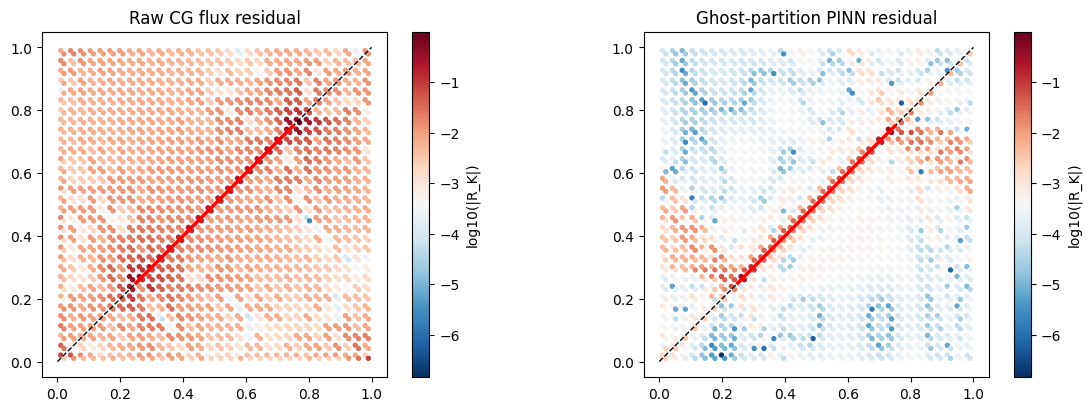

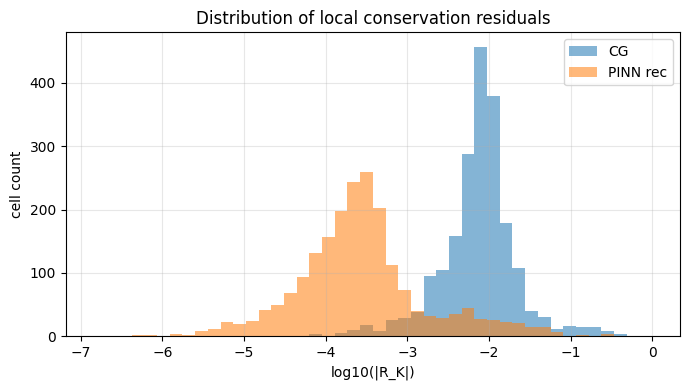

In [39]:
cent = cell_centroids[diag_data["cell_ids"]]

vmin = min(np.log10(np.abs(R_cg) + 1e-16).min(), np.log10(np.abs(R_rec) + 1e-16).min())
vmax = max(np.log10(np.abs(R_cg) + 1e-16).max(), np.log10(np.abs(R_rec) + 1e-16).max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, R, title in [
    (axes[0], R_cg, "Raw CG flux residual"),
    (axes[1], R_rec, "Ghost-partition PINN residual"),
]:
    sc = ax.scatter(
        cent[:, 0],
        cent[:, 1],
        c=np.log10(np.abs(R) + 1e-16),
        s=8,
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )
    ax.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]], "k--", lw=1)
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "r-", lw=2.5)
    ax.set_aspect("equal")
    ax.set_title(title)
    fig.colorbar(sc, ax=ax, label="log10(|R_K|)")
plt.show()

plt.figure(figsize=(7, 4))
lo = vmin
hi = vmax
bins = np.linspace(lo, hi, 45)
plt.hist(np.log10(np.abs(R_cg) + 1e-16), bins=bins, alpha=0.55, label="CG")
plt.hist(np.log10(np.abs(R_rec) + 1e-16), bins=bins, alpha=0.55, label="PINN rec")
plt.xlabel("log10(|R_K|)")
plt.ylabel("cell count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Distribution of local conservation residuals")
plt.tight_layout()
plt.show()

## 11. Save model and arrays

In [40]:
import pathlib

outdir_rec = pathlib.Path("result_ghost_partition_pinn")
outdir_rec.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "q_plus":      q_plus_net.state_dict(),
        "q_minus":     q_minus_net.state_dict(),
        "FRAC_A":      FRAC_A,
        "FRAC_B":      FRAC_B,
        "GHOST_START": GHOST_START,
        "GHOST_END":   GHOST_END,
        "normal":      normal_np,
        "tau":         tau_np,
        "LAMBDA_SIGN": LAMBDA_SIGN,
        "TARGET_MODE": TARGET_MODE,
        "xy_center":   xy_center_np,
        "xy_scale":    xy_scale,
    },
    outdir_rec / "ghost_partition_pinn_flux.pt",
)

np.savez(
    outdir_rec / "diagnostics.npz",
    cell_ids=diag_data["cell_ids"],
    centroids=cent,
    R_cg=R_cg,
    R_rec=R_rec,
    s_real=s_real,
    lambda_target=lambda_target,
    jump_rec=jump_rec,
)

print("saved to", outdir_rec.resolve())


saved to /home/muchamad/PhD/fenicsx/code/fracture problem/result_ghost_partition_pinn


## 12. Jump diagnostics: real fracture and ghost extension

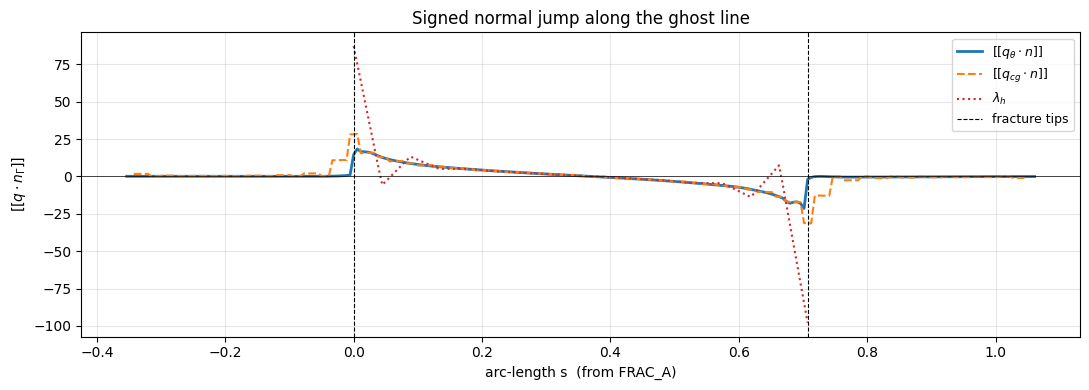

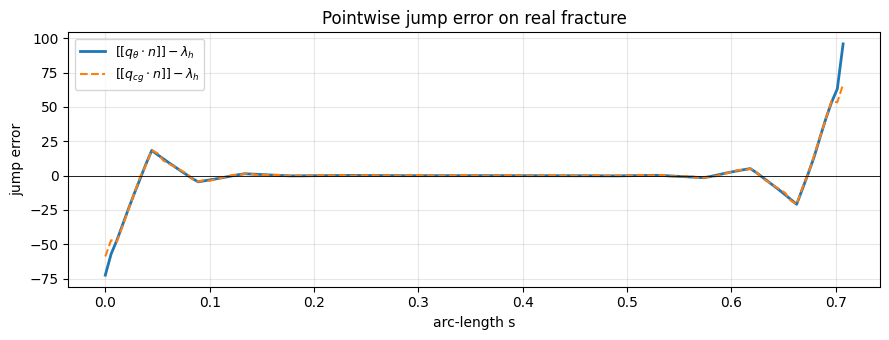

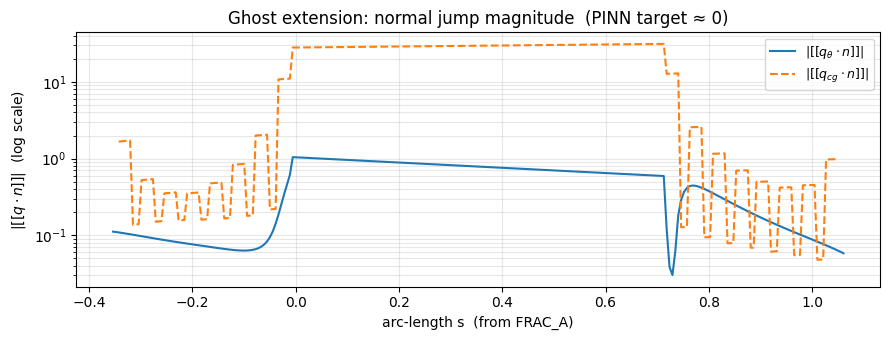

Real fracture jump vs λ_h  (excl. tips):
  PINN — max=5.126e+00  mean=6.498e-01  L2=9.595e-01
  CG   — max=5.003e+00  mean=7.467e-01  L2=9.850e-01
Ghost — max |PINN [[q·n]]|=1.044e+00   max |CG [[q·n]]|=nan


/tmp/ipykernel_579188/3764076451.py:96: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  PINN — max={np.max(np.abs(pinn_err)):.3e}  mean={np.mean(np.abs(pinn_err)):.3e}  L2={np.sqrt(np.trapz(pinn_err**2, s_real[mask_tip])):.3e}")
/tmp/ipykernel_579188/3764076451.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"  CG   — max={np.max(np.abs(cg_err)):.3e}  mean={np.mean(np.abs(cg_err)):.3e}  L2={np.sqrt(np.trapz(cg_err**2,   s_real[mask_tip])):.3e}")


In [41]:

@torch.no_grad()
def jump_and_sides_numpy(pts):
    x_t = to_torch(pts)
    qp = q_plus(x_t).cpu().numpy()
    qm = q_minus(x_t).cpu().numpy()
    qp_n = qp @ normal_np
    qm_n = qm @ normal_np
    return qp_n, qm_n, qp_n - qm_n

# ── arc-length coordinates ──────────────────────────────────────────────
s_ghost_all   = s_coord_np(x_ghost)
mask_left     = s_ghost_all < 0.0
mask_right    = s_ghost_all > L_gamma
x_ghost_left  = x_ghost[mask_left];   s_ghost_left  = s_ghost_all[mask_left]
x_ghost_right = x_ghost[mask_right];  s_ghost_right = s_ghost_all[mask_right]

# ── PINN jumps ──────────────────────────────────────────────────────────
qp_n_real, qm_n_real, jump_pinn_real = jump_and_sides_numpy(x_real)
_, _, jump_pinn_gl  = jump_and_sides_numpy(x_ghost_left)  if len(x_ghost_left)  else (None, None, np.array([]))
_, _, jump_pinn_gr  = jump_and_sides_numpy(x_ghost_right) if len(x_ghost_right) else (None, None, np.array([]))

# ── CG jumps ────────────────────────────────────────────────────────────
jump_cg_real = cg_jump_on_fracture(s_real)
jump_cg_gl   = cg_jump_on_fracture(s_ghost_left)  if len(s_ghost_left)  else np.array([])
jump_cg_gr   = cg_jump_on_fracture(s_ghost_right) if len(s_ghost_right) else np.array([])

# ── λ_h (raw lmbd, no LAMBDA_SIGN) on real fracture ────────────────────
lambda_h_real = eval_fem_function(lmbd, x_real, gamma).reshape(-1)

# ── full ghost-line arrays (ghost_left | fracture | ghost_right) ────────
s_full        = np.concatenate([s_ghost_left, s_real, s_ghost_right])
jump_pinn_all = np.concatenate([jump_pinn_gl, jump_pinn_real, jump_pinn_gr])
jump_cg_all   = np.concatenate([jump_cg_gl,   jump_cg_real,   jump_cg_gr])

# ══════════════════════════════════════════════════════════════════════════
# Figure 1 — signed jump along the full ghost line
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(s_full, jump_pinn_all, color="C0", lw=2,           label=r"$[[q_\theta \cdot n]]$")
ax.plot(s_full, jump_cg_all,   color="C1", lw=1.5, ls="--", label=r"$[[q_{cg} \cdot n]]$")
ax.plot(s_real, lambda_h_real, color="C3", lw=1.5, ls=":",  label=r"$\lambda_h$")
ax.axvline(0.0,     color="k", lw=0.8, ls="--", label="fracture tips")
ax.axvline(L_gamma, color="k", lw=0.8, ls="--")
ax.axhline(0.0, color="k", lw=0.5)
ax.set_xlabel("arc-length s  (from FRAC_A)")
ax.set_ylabel(r"$[[q \cdot n_\Gamma]]$")
ax.set_title("Signed normal jump along the ghost line")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# Figure 2 — pointwise jump error on real fracture
# ══════════════════════════════════════════════════════════════════════════
fig2, ax3 = plt.subplots(figsize=(9, 3.5))
ax3.plot(s_real, jump_pinn_real - lambda_h_real, color="C0", lw=2,
         label=r"$[[q_\theta \cdot n]] - \lambda_h$")
ax3.plot(s_real, jump_cg_real   - lambda_h_real, color="C1", lw=1.5, ls="--",
         label=r"$[[q_{cg} \cdot n]] - \lambda_h$")
ax3.axhline(0.0, color="k", lw=0.6)
ax3.set_xlabel("arc-length s")
ax3.set_ylabel("jump error")
ax3.set_title("Pointwise jump error on real fracture")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# Figure 3 — ghost extension jump magnitude
# ══════════════════════════════════════════════════════════════════════════
s_ghost_only   = np.concatenate([s_ghost_left, s_ghost_right])
jp_ghost_only  = np.concatenate([jump_pinn_gl, jump_pinn_gr])
jcg_ghost_only = np.concatenate([jump_cg_gl,   jump_cg_gr])

if len(s_ghost_only):
    fig3, ax4 = plt.subplots(figsize=(9, 3.5))
    ax4.semilogy(s_ghost_only, np.abs(jp_ghost_only)  + 1e-16, color="C0", lw=1.5,
                 label=r"$|[[q_\theta \cdot n]]|$")
    ax4.semilogy(s_ghost_only, np.abs(jcg_ghost_only) + 1e-16, color="C1", lw=1.5, ls="--",
                 label=r"$|[[q_{cg} \cdot n]]|$")
    ax4.set_xlabel("arc-length s  (from FRAC_A)")
    ax4.set_ylabel(r"$|[[q \cdot n]]|$  (log scale)")
    ax4.set_title("Ghost extension: normal jump magnitude  (PINN target ≈ 0)")
    ax4.legend(fontsize=9)
    ax4.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── Summary numbers ─────────────────────────────────────────────────────
mask_tip  = (s_real >= TIP_FRAC * L_gamma) & (s_real <= (1 - TIP_FRAC) * L_gamma)
pinn_err  = jump_pinn_real[mask_tip] - lambda_h_real[mask_tip]
cg_err    = jump_cg_real[mask_tip]   - lambda_h_real[mask_tip]
print("Real fracture jump vs λ_h  (excl. tips):")
print(f"  PINN — max={np.max(np.abs(pinn_err)):.3e}  mean={np.mean(np.abs(pinn_err)):.3e}  L2={np.sqrt(np.trapz(pinn_err**2, s_real[mask_tip])):.3e}")
print(f"  CG   — max={np.max(np.abs(cg_err)):.3e}  mean={np.mean(np.abs(cg_err)):.3e}  L2={np.sqrt(np.trapz(cg_err**2,   s_real[mask_tip])):.3e}")
if len(s_ghost_only):
    print(f"Ghost — max |PINN [[q·n]]|={np.max(np.abs(jp_ghost_only)):.3e}   max |CG [[q·n]]|={np.max(np.abs(jcg_ghost_only)):.3e}")

## 13. Local conservation around fracture and ghost extension


Fracture-adjacent cells : 32
Ghost extension cells   : 146


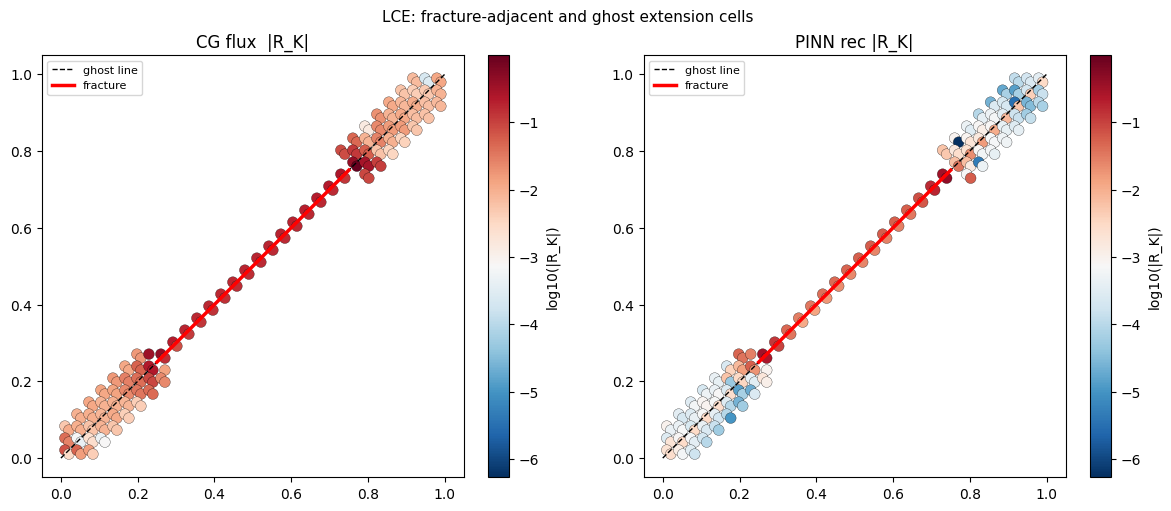

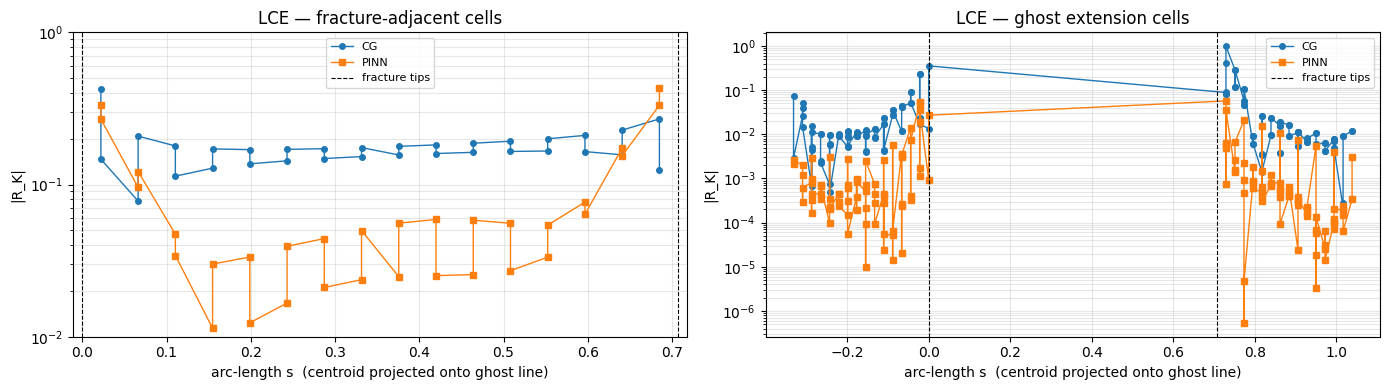

Fracture-adjacent cells  (n=32):
  CG   mean|R| = 1.757e-01   max|R| = 4.255e-01
  PINN mean|R| = 8.857e-02   max|R| = 4.301e-01

Ghost extension cells  (n=146):
  CG   mean|R| = 3.867e-02   max|R| = 9.901e-01
  PINN mean|R| = 3.282e-03   max|R| = 5.704e-02



In [42]:
# ── Identify fracture-adjacent cells ──────────────────────────────────────
frac_cell_ids = np.unique([cell_id for cell_id, _, _, _ in gamma_facet_records])

# ── Identify ghost extension cells (near ghost line, outside fracture) ─────
d_ghost_thresh = 2.5 * h_est
phi_cent_all = signed_distance_np(cell_centroids)
s_cent_all   = s_coord_np(cell_centroids)
ghost_mask = (
    (np.abs(phi_cent_all) < d_ghost_thresh) &
    ((s_cent_all < 0.0) | (s_cent_all > L_gamma))
)
ghost_cell_ids = np.where(ghost_mask)[0]

# R_cg / R_rec are indexed directly by cell index (diag_data['cell_ids'] = arange)
R_cg_frac   = R_cg[frac_cell_ids]
R_rec_frac  = R_rec[frac_cell_ids]
R_cg_ghost  = R_cg[ghost_cell_ids]
R_rec_ghost = R_rec[ghost_cell_ids]

cent_frac  = cell_centroids[frac_cell_ids]
cent_ghost = cell_centroids[ghost_cell_ids]
s_frac     = s_coord_np(cent_frac)
s_ghost    = s_coord_np(cent_ghost)

print(f'Fracture-adjacent cells : {len(frac_cell_ids)}')
print(f'Ghost extension cells   : {len(ghost_cell_ids)}')

# ── Figure 1: scatter residual map (fracture + ghost cells only) ───────────
all_ids   = np.concatenate([frac_cell_ids, ghost_cell_ids])
all_R_cg  = np.concatenate([R_cg_frac,  R_cg_ghost])
all_R_rec = np.concatenate([R_rec_frac, R_rec_ghost])
cent_all  = cell_centroids[all_ids]

vmin = min(np.log10(np.abs(all_R_cg)  + 1e-16).min(),
           np.log10(np.abs(all_R_rec) + 1e-16).min())
vmax = max(np.log10(np.abs(all_R_cg)  + 1e-16).max(),
           np.log10(np.abs(all_R_rec) + 1e-16).max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, R, title in [
    (axes[0], all_R_cg,  'CG flux  |R_K|'),
    (axes[1], all_R_rec, 'PINN rec |R_K|'),
]:
    sc = ax.scatter(cent_all[:, 0], cent_all[:, 1],
                    c=np.log10(np.abs(R) + 1e-16),
                    s=60, cmap='RdBu_r', vmin=vmin, vmax=vmax, edgecolors='k', linewidths=0.2)
    ax.plot([GHOST_START[0], GHOST_END[0]], [GHOST_START[1], GHOST_END[1]], 'k--', lw=1, label='ghost line')
    ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], 'r-', lw=2.5, label='fracture')
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.legend(fontsize=8)
    fig.colorbar(sc, ax=ax, label='log10(|R_K|)')
plt.suptitle('LCE: fracture-adjacent and ghost extension cells', fontsize=11)
plt.show()

# ── Figure 2: |R_K| vs arc-length s ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, R_cg_f, R_rec_f, s_f, label in [
    (axes[0], R_cg_frac,  R_rec_frac,  s_frac,  'fracture-adjacent'),
    (axes[1], R_cg_ghost, R_rec_ghost, s_ghost, 'ghost extension'),
]:
    sort_idx = np.argsort(s_f)
    ax.semilogy(s_f[sort_idx], np.abs(R_cg_f[sort_idx]),
                'o-', ms=4, lw=1, color='C0', label='CG')
    ax.semilogy(s_f[sort_idx], np.abs(R_rec_f[sort_idx]),
                's-', ms=4, lw=1, color='C1', label='PINN')
    ax.axvline(0.0,     color='k', lw=0.8, ls='--', label='fracture tips')
    ax.axvline(L_gamma, color='k', lw=0.8, ls='--')
    ax.set_xlabel('arc-length s  (centroid projected onto ghost line)')
    ax.set_ylabel('|R_K|')
    ax.set_title(f'LCE — {label} cells')
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylim(1e-2, 1e0)   # <-- choose limits you want

plt.tight_layout()
plt.show()

# ── Summary stats ───────────────────────────────────────────────────────────
for label, ids, R_cg_f, R_rec_f in [
    ('Fracture-adjacent', frac_cell_ids,  R_cg_frac,  R_rec_frac),
    ('Ghost extension',   ghost_cell_ids, R_cg_ghost, R_rec_ghost),
]:
    if len(ids) == 0:
        print(f'{label}: no cells found')
        continue
    print(f'{label} cells  (n={len(ids)}):')
    print(f'  CG   mean|R| = {np.mean(np.abs(R_cg_f)):.3e}   max|R| = {np.max(np.abs(R_cg_f)):.3e}')
    print(f'  PINN mean|R| = {np.mean(np.abs(R_rec_f)):.3e}   max|R| = {np.max(np.abs(R_rec_f)):.3e}')
    print()


### Tip vs interior contribution to plateaued losses


In [43]:
tip_pt = (s_real < TIP_FRAC * L_gamma) | (s_real > (1.0 - TIP_FRAC) * L_gamma)
int_pt = ~tip_pt

jump_diag = jump_rec_numpy(s_real)
err_jump = jump_diag - lambda_target
jump_terms = w_tip * err_jump ** 2

def _subset_contribution(vals, mask):
    return float(np.sum(vals[mask]) / max(len(vals), 1))

print('Jump loss split (current model, same scale as logged jump loss):')
print(f'  all mean          : {np.mean(jump_terms):.3e}')
if len(history):
    print(f"  last logged       : {history[-1].get('jump', np.nan):.3e}")
print(f'  tip contribution : {_subset_contribution(jump_terms, tip_pt):.3e}  (n={np.count_nonzero(tip_pt)})')
print(f'  int contribution : {_subset_contribution(jump_terms, int_pt):.3e}  (n={np.count_nonzero(int_pt)})')
if np.count_nonzero(tip_pt):
    print(f'  tip mean          : {np.mean(jump_terms[tip_pt]):.3e}')
if np.count_nonzero(int_pt):
    print(f'  int mean          : {np.mean(jump_terms[int_pt]):.3e}')

tip_cell = (s_frac < TIP_FRAC * L_gamma) | (s_frac > (1.0 - TIP_FRAC) * L_gamma)
int_cell = ~tip_cell

def _print_lce_split(name, R):
    vals = R ** 2
    print(f'\n{name} conservation residual split:')
    print(f'  all mean(R^2)      : {np.mean(vals):.3e}')
    for label, mask in [('tip', tip_cell), ('int', int_cell)]:
        n = np.count_nonzero(mask)
        if n == 0:
            print(f'  {label} cells          : none')
            continue
        print(f'  {label} contribution  : {_subset_contribution(vals, mask):.3e}  (n={n})')
        print(f'  {label} mean(R^2)      : {np.mean(vals[mask]):.3e}')
        print(f'  {label} max|R|         : {np.max(np.abs(R[mask])):.3e}')
    print(f'  all mean|R|        : {np.mean(np.abs(R)):.3e}')

_print_lce_split('PINN', R_rec_frac)
_print_lce_split('CG', R_cg_frac)

if np.count_nonzero(int_cell):
    ratio = (np.abs(R_rec_frac[int_cell]) + 1e-16) / (np.abs(R_cg_frac[int_cell]) + 1e-16)
    print('\nInterior PINN-vs-CG conservation:')
    print(f'  improved cells       : {100.0 * np.mean(ratio < 1.0):.1f}%')
    print(f'  mean |PINN|/|CG|    : {np.mean(ratio):.3e}')
    print(f'  median |PINN|/|CG|  : {np.median(ratio):.3e}')
    print(f'  max |PINN|/|CG|     : {np.max(ratio):.3e}')


Jump loss split (current model, same scale as logged jump loss):
  all mean          : 9.623e-02
  last logged       : 9.673e-02
  tip contribution : 5.646e-02  (n=26)
  int contribution : 3.977e-02  (n=102)
  tip mean          : 2.780e-01
  int mean          : 4.990e-02

PINN conservation residual split:
  all mean(R^2)      : 1.876e-02
  tip contribution  : 1.743e-02  (n=8)
  tip mean(R^2)      : 6.972e-02
  tip max|R|         : 4.301e-01
  int contribution  : 1.333e-03  (n=24)
  int mean(R^2)      : 1.777e-03
  int max|R|         : 7.665e-02
  all mean|R|        : 8.857e-02

CG conservation residual split:
  all mean(R^2)      : 3.405e-02
  tip contribution  : 1.303e-02  (n=8)
  tip mean(R^2)      : 5.211e-02
  tip max|R|         : 4.255e-01
  int contribution  : 2.102e-02  (n=24)
  int mean(R^2)      : 2.803e-02
  int max|R|         : 2.102e-01
  all mean|R|        : 1.757e-01

Interior PINN-vs-CG conservation:
  improved cells       : 100.0%
  mean |PINN|/|CG|    : 2.250e-01
  med